Notebook for constructing "connectivity matrices" in the form of binary connections or PSP Amplitude from the AISYNPHYS dataset.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
from IPython.display import display, Markdown
from pathlib import Path
import os
import math

# AISYNPHYS stuff
import pyqtgraph
import neuroanalysis
import neuroanalysis.util
import aisynphys
import aisynphys.database

# Prints
print(aisynphys.__file__)
print(pyqtgraph.__file__)
print(neuroanalysis.__file__)

# Load matplotlib style
plt.style.use('plos.mplstyle')

# File path handling
# SCRIPT_DIR = Path(__file__).resolve().parent  # .py
SCRIPT_DIR = Path.cwd()  # .ipynb
FIGURES_DIR = SCRIPT_DIR / "figures_analysis"
print(f"Figure path: {FIGURES_DIR}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------

# Load DB
from aisynphys.database import SynphysDatabase # https://aisynphys.readthedocs.io/en/current-release/database_access.html#database-access



CACHE_PATH = Path("data/aisynphys/cache").resolve()  # Define cache directory
CACHE_PATH.mkdir(parents=True, exist_ok=True)  # Create a cache directory if it does not exist
aisynphys.config.cache_path = CACHE_PATH  # Tell AISynPhys to use this cache
DATA_ROOT = Path("data/aisynphys/cache")  # Make cache
SynphysDatabase.list_versions()  # List all available versions


# DB_VERSION = 'synphys_r2.1_medium.sqlite'  # Medium database
DB_VERSION = 'synphys_r2.1_full.sqlite'  # Full database

db = SynphysDatabase.load_version(DB_VERSION)  # Load DB
print(f"Loaded version: {DB_VERSION}")

# ------------------------------------------------------------
# Set up connection


# DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_medium.sqlite').resolve()  # Medium database
DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_full.sqlite').resolve()  # Full database
assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"  # Ensure existence


con = sqlite3.connect(DB_PATH)  # Create SQLite connection to SQLite database
con.create_function("SQRT", 1, math.sqrt)   # now SQLite understands SQRT()
cur = con.cursor()  # database cursor
print(f"Connection set up to {DB_PATH}")

C:\Users\snrambo\aisynphys\aisynphys\__init__.py
c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\pyqtgraph\__init__.py
C:\Users\snrambo\neuroanalysis\neuroanalysis\__init__.py
Figure path: c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\data_analysis\figures_analysis
Loaded version: synphys_r2.1_full.sqlite
Connection set up to C:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\data_analysis\data\aisynphys\cache\database\synphys_r2.1_full.sqlite


In [2]:
query = """ 
SELECT
    p.experiment_id,
    p.pre_cell_id,
    p.post_cell_id,
    p.has_synapse,
    pre.cell_class  AS pre_cell_class,
    post.cell_class AS post_cell_class,
    i_pre.fi_slope  AS fi_slope_pre,   -- presynaptic fI slope
    i_post.fi_slope AS fi_slope_post,  -- postsynaptic fI slope
    CASE
        WHEN p.has_synapse = 1 THEN syn.psp_amplitude
        ELSE NULL                     -- to keep entries where there was not a synapse
    END AS psp_amplitude
FROM pair AS p
JOIN cell       AS pre   ON p.pre_cell_id  = pre.id  
JOIN cell       AS post  ON p.post_cell_id = post.id
JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id
JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id
LEFT JOIN synapse AS syn   ON syn.pair_id = p.id          -- can be NULL
JOIN experiment AS e     ON e.id = p.experiment_id
JOIN slice      AS s     ON e.slice_id = s.id
WHERE
    s.species = 'mouse'
    AND i_pre.fi_slope IS NOT NULL
    AND i_post.fi_slope IS NOT NULL
    AND p.has_synapse IS NOT NULL   -- only defined synapses
    AND syn.psp_amplitude IS NOT NULL
    ;

        """

main = pd.read_sql_query(query, con)
df_valid_experiments = main.copy()

df_valid_experiments

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
0,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,-0.000204
1,600,4140,4133,1,ex,in,1.131452e-13,8.230065e-13,0.000445
2,610,4199,4201,1,ex,ex,-1.923071e-15,7.692308e-14,0.000030
3,614,4225,4227,1,in,ex,6.599999e-13,2.000000e-13,-0.000168
4,699,4698,4700,1,ex,in,1.158730e-13,-1.269841e-14,0.000038
...,...,...,...,...,...,...,...,...,...
616,5004,24565,24564,1,in,in,4.807973e-13,1.739197e-13,-0.001123
617,5004,24567,24564,1,in,in,7.191986e-13,1.739197e-13,-0.000221
618,5105,24778,24781,1,mixed,ex,8.018796e-13,9.525691e-14,-0.000198
619,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,-0.000314


In [3]:
unique_exp = df_valid_experiments["experiment_id"].unique()
print(len(unique_exp))

316


# Binary matrix

Number of experiments in original DF: 316
Number of experiments in the grouped DF: 140
140
Total experiments: 140


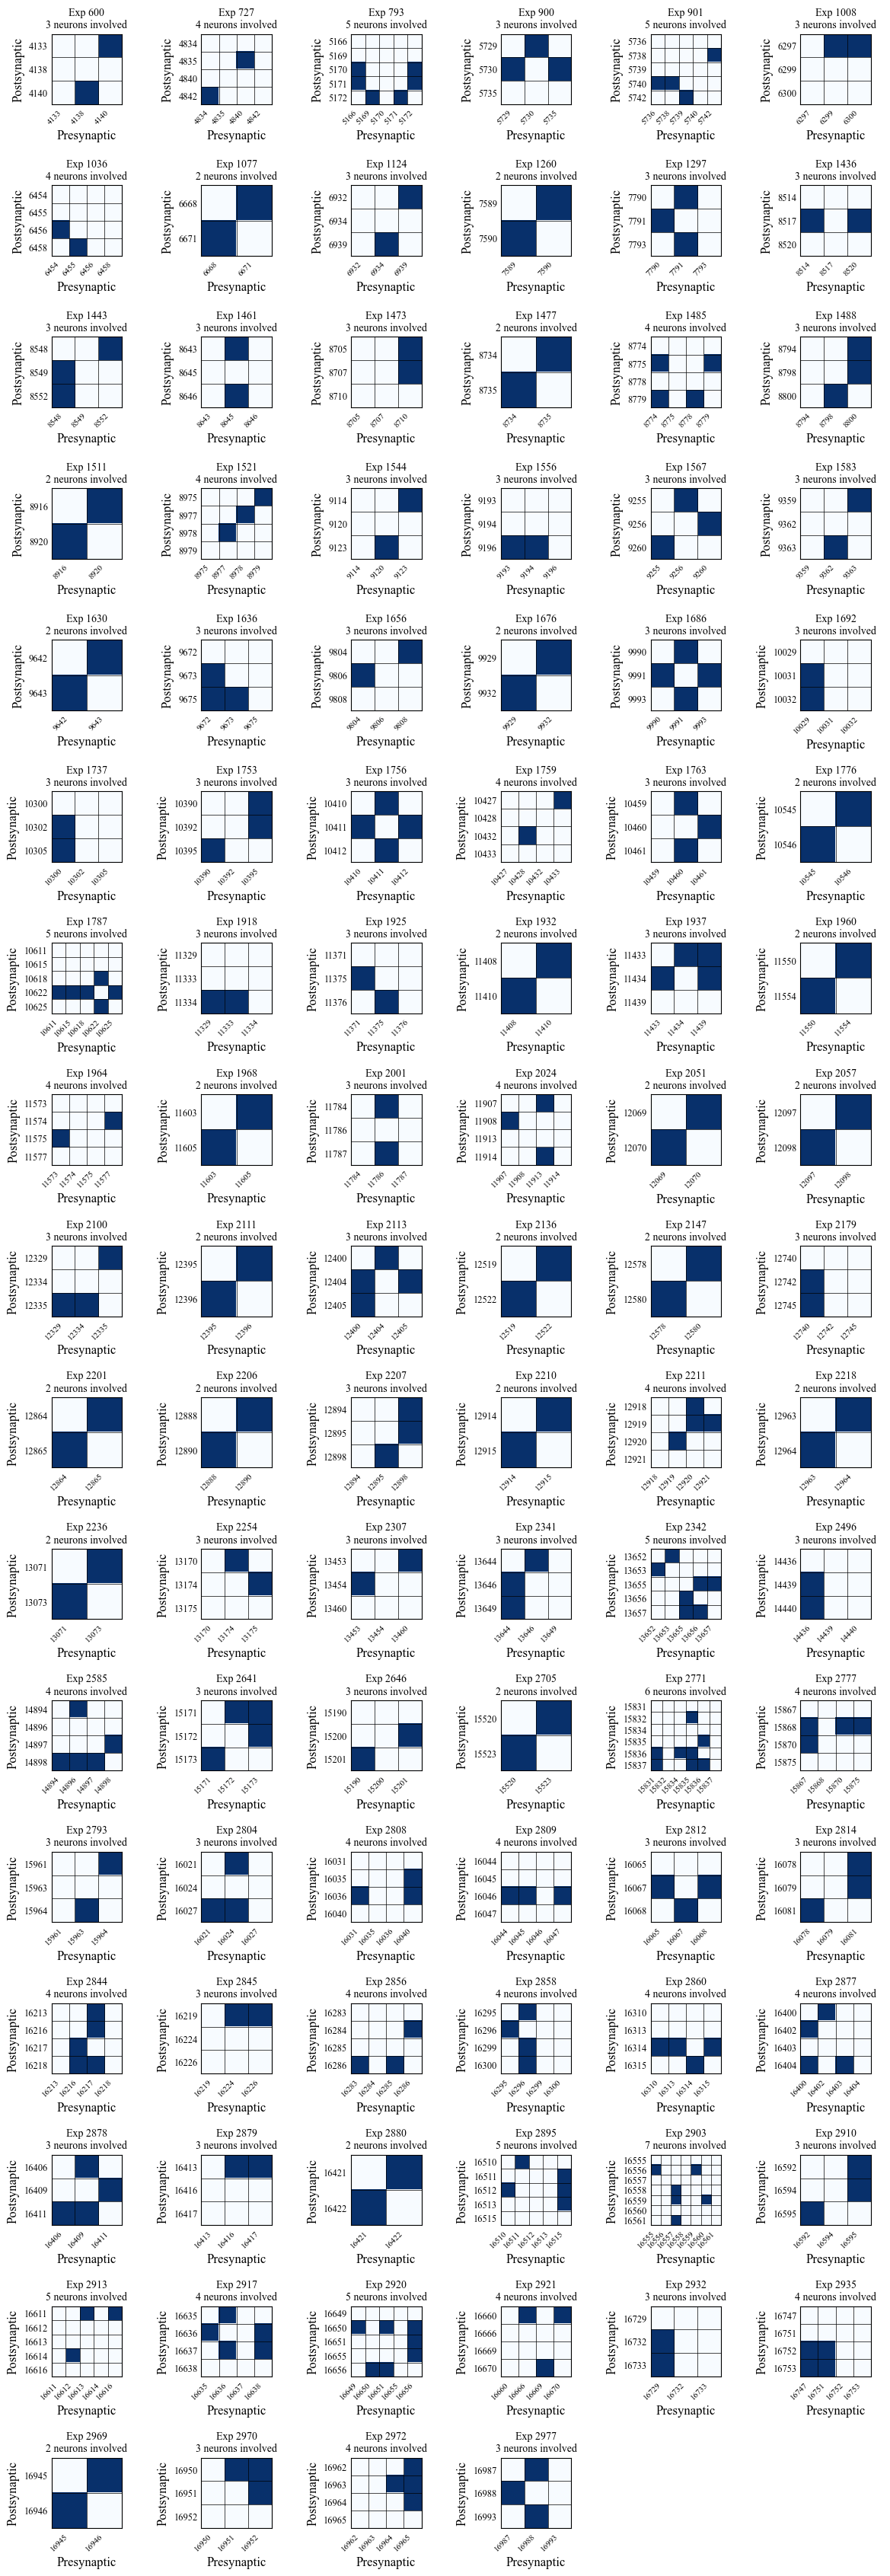

In [4]:
completed_experiments = []

query = """ 
SELECT
    p.experiment_id,
    p.pre_cell_id,
    p.post_cell_id,
    p.has_synapse,
    pre.cell_class  AS pre_cell_class,
    post.cell_class AS post_cell_class,
    i_pre.fi_slope  AS fi_slope_pre,   -- presynaptic fI slope
    i_post.fi_slope AS fi_slope_post,  -- postsynaptic fI slope
    CASE
        WHEN p.has_synapse = 1 THEN syn.psp_amplitude
        ELSE NULL                     -- to keep entries where there was not a synapse
    END AS psp_amplitude
FROM pair AS p
JOIN cell       AS pre   ON p.pre_cell_id  = pre.id  
JOIN cell       AS post  ON p.post_cell_id = post.id
JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id
JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id
LEFT JOIN synapse AS syn   ON syn.pair_id = p.id          -- can be NULL
JOIN experiment AS e     ON e.id = p.experiment_id
JOIN slice      AS s     ON e.slice_id = s.id
WHERE
    s.species = 'mouse'
    AND i_pre.fi_slope IS NOT NULL
    AND i_post.fi_slope IS NOT NULL
    AND p.has_synapse IS NOT NULL   -- only defined synapses
    AND syn.psp_amplitude IS NOT NULL
    ;
        """

main = pd.read_sql_query(query, con)
df_valid_experiments = main.copy()

unique_exp = df_valid_experiments["experiment_id"].unique()
print(f"Number of experiments in original DF: {len(unique_exp)}")

# -------------------- Specific experiments --------------------
# Query for experiments satisfying a specific criteria, here above a certain number of synapses

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p
            INNER JOIN cell       AS pre   ON p.pre_cell_id  = pre.id  
            INNER JOIN cell       AS post  ON p.post_cell_id = post.id
            INNER JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id
            INNER JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id
            LEFT JOIN synapse AS syn   ON syn.pair_id = p.id          -- can be NULL
            INNER JOIN experiment AS e     ON e.id = p.experiment_id
            INNER JOIN slice      AS s     ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse'
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                AND p.has_synapse IS NOT NULL   -- only defined synapses
                AND syn.psp_amplitude IS NOT NULL
                
            GROUP BY p.experiment_id
            HAVING num_synapses > 1
            ;
        """

experiments = pd.read_sql_query(query, con)

unique_exp = experiments["experiment_id"].unique()
print(f"Number of experiments in the grouped DF: {len(unique_exp)}")

experiment_ids = experiments["experiment_id"].unique().tolist()
print(len(experiment_ids))



completed_experiments = []

for exp in experiment_ids:
    df = df_valid_experiments[df_valid_experiments["experiment_id"] == exp].copy()

    if df.empty:
        continue

    pres = df["pre_cell_id"].unique().tolist()
    posts = df["post_cell_id"].unique().tolist()
    # total_neurons = list(set(pres) | set(posts))
    total_neurons = sorted(set(pres) | set(posts))

    completed_experiments.append((exp, df, total_neurons))

print(f"Total experiments: {len(completed_experiments)}")





# print(completed_experiments)

# Plot the first 100 valid experiments
n_max = min(100, len(experiment_ids))
n_cols = 6
n_rows = int(np.ceil(n_max / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axs = axs.flatten()

flag = 0

rows = []

# Make adjacency matrices
for i, (exp, df, total_neurons) in enumerate(completed_experiments[:n_max]):
    n = len(total_neurons)
    idx_map = {neuron: idx for idx, neuron in enumerate(total_neurons)}  # mapping neuron to index
    adj = np.zeros((n, n))

    synapses = []

    for _, row in df.iterrows():  # iterates through the dataframe
        flag += 1
        pre = row["pre_cell_id"]
        post = row['post_cell_id']
        i_pre = idx_map[pre]
        i_post = idx_map[post]
        # adj[i_pre, i_post] = 1 if row["has_synapse"] == 1 else 0 # ??????? other way around maybe
        adj[i_post, i_pre] = 1 if row["has_synapse"] == 1 else 0  # row is postsynaptic, column is presynaptic


    ax = axs[i]
    im = ax.imshow(adj, cmap="Blues", interpolation='none')

    # (n, n) matrix with cell centers at 0, 1, 2, ..., n-1, and cell borders at -0.5, 0.5, 1.5, ..., n-0.5
    # include minor and major ticks

    neurons = adj.shape[0]

    # Major ticks (centers)
    ax.set_xticks(np.arange(neurons))
    ax.set_yticks(np.arange(neurons))

    # Labels 0 to n-1
    labels = [neuron for neuron, _ in sorted(idx_map.items(), key=lambda x: x[1])]
    # ax.set_xticklabels(labels)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels)

    # Minor ticks (borders)
    ax.set_xticks(np.arange(-.5, neurons, 1), minor=True)
    ax.set_yticks(np.arange(-.5, neurons, 1), minor=True)

    # Draw grid using minor ticks
    ax.grid(which="minor", color='black', linestyle='-', linewidth=0.5)

    # Hide minor tick marks themselves
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(which="major", bottom=False, left=False)


    ax.set_title(f"Exp {exp}\n{n} neurons involved", fontsize=10)
    ax.set_xlabel("Presynaptic")
    ax.set_ylabel("Postsynaptic")

    ax.set_xlim(-0.5, (neurons - 0.5))
    ax.set_ylim((neurons - 0.5), -0.5) # flipped y axis?



# Hide extra axes
for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

# PSP Matrix

Number of experiments in original DF: 316
Number of experiments in the grouped DF: 140
Total experiments: 140


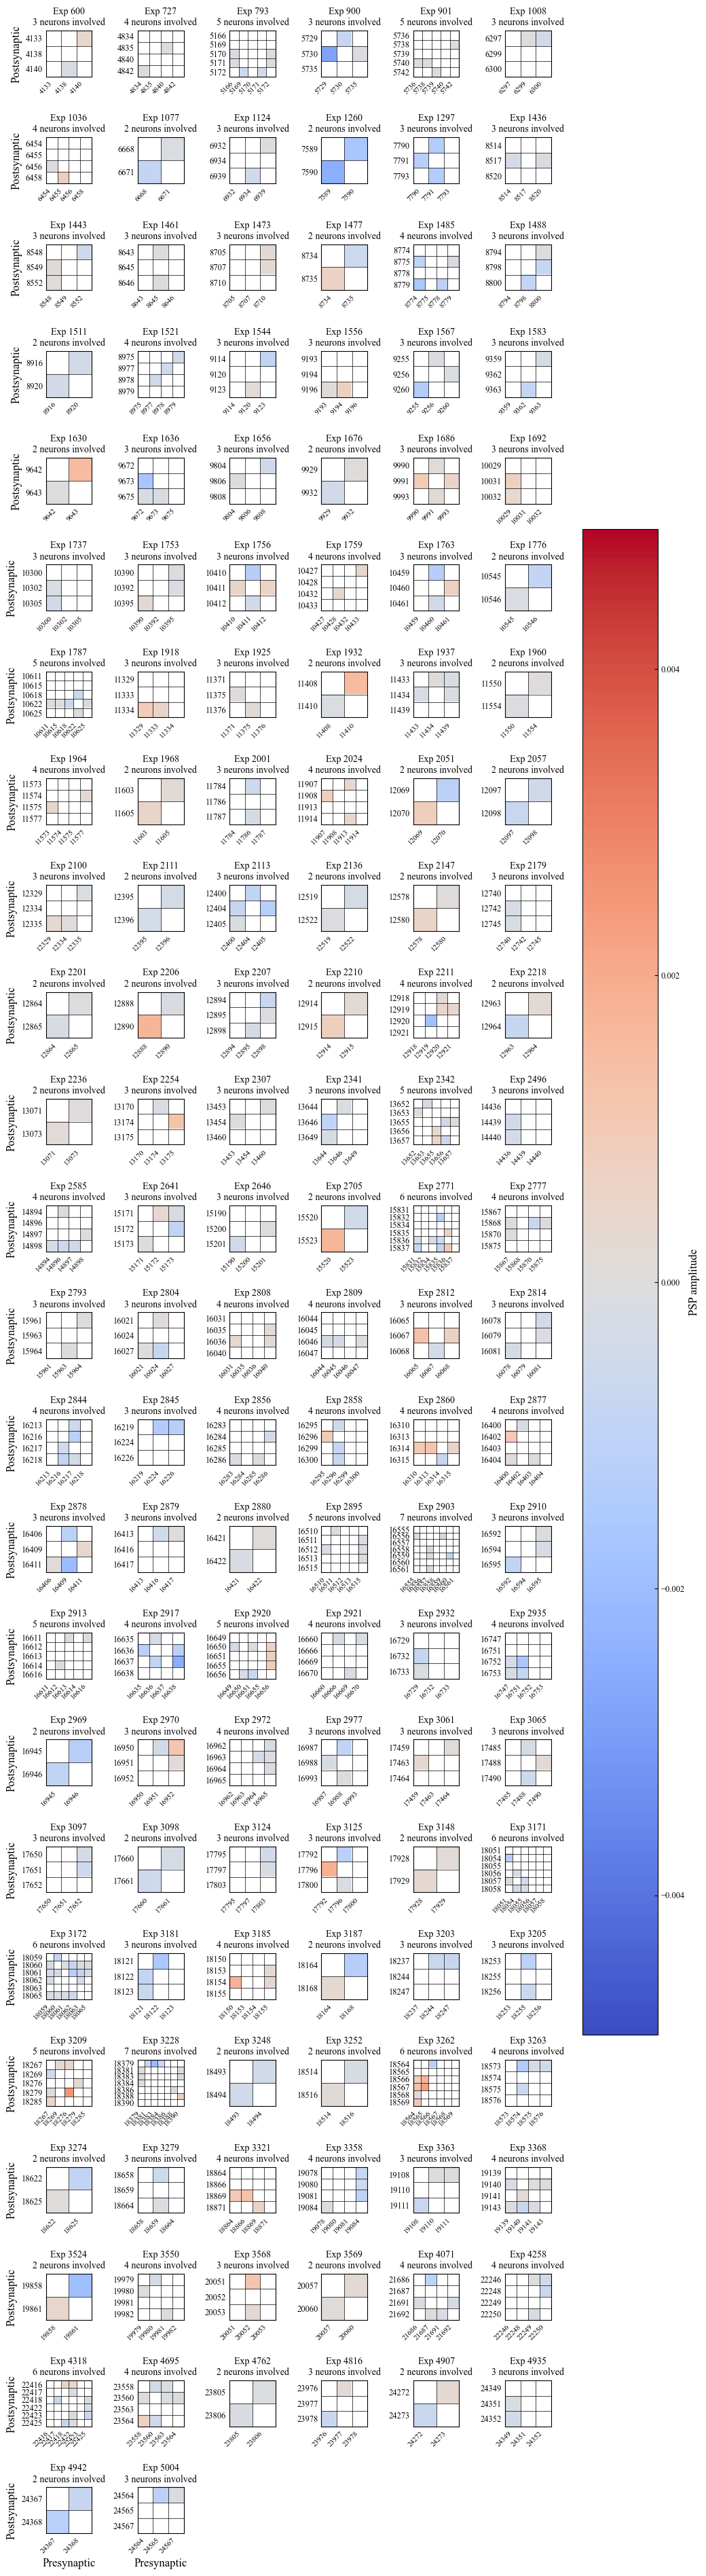

In [3]:
import os

completed_experiments = []

query = """ 
SELECT
    p.experiment_id,
    p.pre_cell_id,
    p.post_cell_id,
    p.has_synapse,
    pre.cell_class  AS pre_cell_class,
    post.cell_class AS post_cell_class,
    i_pre.fi_slope  AS fi_slope_pre,   -- presynaptic fI slope
    i_post.fi_slope AS fi_slope_post,  -- postsynaptic fI slope
    CASE
        WHEN p.has_synapse = 1 THEN syn.psp_amplitude
        ELSE NULL                     -- to keep entries where there was not a synapse
    END AS psp_amplitude
FROM pair AS p
JOIN cell       AS pre   ON p.pre_cell_id  = pre.id  
JOIN cell       AS post  ON p.post_cell_id = post.id
JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id
JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id
LEFT JOIN synapse AS syn   ON syn.pair_id = p.id          -- can be NULL
JOIN experiment AS e     ON e.id = p.experiment_id
JOIN slice      AS s     ON e.slice_id = s.id
WHERE
    s.species = 'mouse'
    AND i_pre.fi_slope IS NOT NULL
    AND i_post.fi_slope IS NOT NULL
    AND p.has_synapse IS NOT NULL   -- only defined synapses
    AND syn.psp_amplitude IS NOT NULL
    ;

        """

main = pd.read_sql_query(query, con)
df_valid_experiments = main.copy()

unique_exp = df_valid_experiments["experiment_id"].unique()
print(f"Number of experiments in original DF: {len(unique_exp)}")


vmax = np.nanmax(np.abs(df_valid_experiments["psp_amplitude"]))
vmin = -vmax

# -------------------- Specific experiments --------------------
# Query for experiments satisfying a specific criteria, here above a certain number of synapses

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p
            INNER JOIN cell       AS pre   ON p.pre_cell_id  = pre.id  
            INNER JOIN cell       AS post  ON p.post_cell_id = post.id
            INNER JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id
            INNER JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id
            LEFT JOIN synapse AS syn   ON syn.pair_id = p.id          -- can be NULL
            INNER JOIN experiment AS e     ON e.id = p.experiment_id
            INNER JOIN slice      AS s     ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse'
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                AND p.has_synapse IS NOT NULL   -- only defined synapses
                AND syn.psp_amplitude IS NOT NULL
                
            GROUP BY p.experiment_id
            HAVING num_synapses > 1
            ;
        """

experiments = pd.read_sql_query(query, con)

unique_exp = experiments["experiment_id"].unique()
print(f"Number of experiments in the grouped DF: {len(unique_exp)}")

experiment_ids = experiments["experiment_id"].unique().tolist()

# df_valid_experiments = df_valid_experiments.dropna(subset=["psp_amplitude"])

completed_experiments = []

for exp in experiment_ids:
    df = df_valid_experiments[df_valid_experiments["experiment_id"] == exp].copy()

    if df.empty:
        continue

    pres = df["pre_cell_id"].unique().tolist()
    posts = df["post_cell_id"].unique().tolist()
    # total_neurons = list(set(pres) | set(posts))
    total_neurons = sorted(set(pres) | set(posts))

    completed_experiments.append((exp, df, total_neurons))

print(f"Total experiments: {len(completed_experiments)}")


# print(completed_experiments)

# Plot the first 100 valid experiments
# n_max = min(100, len(completed_experiments))
n_max = len(completed_experiments)  # all
n_cols = 6
n_rows = int(np.ceil(n_max / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
plt.subplots_adjust(wspace=1, hspace=1)

axs = axs.flatten()

flag = 0

rows = []

# Make adjacency matrices
for i, (exp, df, total_neurons) in enumerate(completed_experiments[:n_max]):
    n = len(total_neurons)
    idx_map = {neuron: idx for idx, neuron in enumerate(total_neurons)}  # mapping neuron to index
    # adj = np.zeros((n, n))
    adj = np.full((n, n), np.nan)   # missing / no measurement stays blank

    synapses = []

    for _, row in df.iterrows():  # iterates through the dataframe
        flag += 1
        pre = row["pre_cell_id"]
        post = row['post_cell_id']
        i_pre = idx_map[pre]
        i_post = idx_map[post]

        adj[i_post, i_pre] = row["psp_amplitude"]

    # Saving psp matrices for later computation:

    save_dir = "psp_matrices"
    os.makedirs(save_dir, exist_ok=True)

    labels = [neuron for neuron, _ in sorted(idx_map.items(), key=lambda x: x[1])]

    adj_df = pd.DataFrame(
        adj,
        index=labels,    # postsynaptic neurons
        columns=labels   # presynaptic neurons
    )

    adj_df.to_csv(f"{save_dir}/experiment_{exp}.csv")

    # Saving as NumPy arrays
    
    save_dir = "psp_arrays"
    os.makedirs(save_dir, exist_ok=True)

    np.save(f"{save_dir}/experiment_{exp}.npy", adj)


    ax = axs[i]
    # im = ax.imshow(adj, cmap="Blues", interpolation='none')
    im = ax.imshow(
    adj,
    cmap="coolwarm",      # negative to positive
    vmin=vmin,
    vmax=vmax,
    interpolation="none"
    )

    # (n, n) matrix with cell centers at 0, 1, 2, ..., n-1, and cell borders at -0.5, 0.5, 1.5, ..., n-0.5
    # include minor and major ticks

    neurons = adj.shape[0]

    row = i // n_cols
    col = i % n_cols

    # Major ticks (centers)
    ax.set_xticks(np.arange(neurons))
    ax.set_yticks(np.arange(neurons))

    # Labels 0 to n-1
    labels = [neuron for neuron, _ in sorted(idx_map.items(), key=lambda x: x[1])]
    fi_rows = []
    for neuron in labels:
        pre_vals = df.loc[df["pre_cell_id"] == neuron, "fi_slope_pre"]
        post_vals = df.loc[df["post_cell_id"] == neuron, "fi_slope_post"]

        #  should be identical per neuron, but combine both roles safely
        vals = pd.concat([pre_vals, post_vals]).dropna().unique()

        fi_rows.append({
            "experiment_id": exp,
            "cell_id": neuron,
            "matrix_index": idx_map[neuron],
            "fi_slope": vals[0] if len(vals) > 0 else np.nan
        })

    fi_df = pd.DataFrame(fi_rows)

    meta_dir = "psp_metadata"
    os.makedirs(meta_dir, exist_ok=True)

    fi_df.to_csv(f"{meta_dir}/experiment_{exp}_fi_slopes.csv", index=False)

    # ax.set_xticklabels(labels)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels)

    # Minor ticks (borders)
    ax.set_xticks(np.arange(-.5, neurons, 1), minor=True)
    ax.set_yticks(np.arange(-.5, neurons, 1), minor=True)

    # Draw grid using minor ticks
    ax.grid(which="minor", color='black', linestyle='-', linewidth=0.5)

    # Hide minor tick marks themselves
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(which="major", bottom=False, left=False)


    ax.set_title(f"Exp {exp}\n{n} neurons involved", fontsize=10)
    if col == 0:
        ax.set_ylabel("Postsynaptic")
    if row == n_rows - 1:
        ax.set_xlabel("Presynaptic")

    ax.set_xlim(-0.5, (neurons - 0.5))
    ax.set_ylim((neurons - 0.5), -0.5) # flipped y axis?



# Hide extra axes
for j in range(i+1, len(axs)):
    axs[j].axis('off')

fig.colorbar(im, ax=axs[:n_max], shrink=0.6, label="PSP amplitude")
# plt.tight_layout()
plt.show()

# Save and load

In [6]:
# NumPy
adj = np.load("psp_arrays/experiment_600.npy")
print(adj.shape)

# csv to pandas (Includes header and column names, so this need to be accounted for in computation)
df = pd.read_csv("psp_matrices/experiment_600.csv")
df

(3, 3)


,Unnamed: 0,4133,4138,4140
0,4133,NaN,NaN,0.000445
1,4138,NaN,NaN,NaN
2,4140,NaN,-0.000204,NaN
